**Section 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

**Section 2: Load Dataset**

In [2]:
df = pd.read_csv(
    "../data/processed/ev_sales_cleaned.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Year,Month,State,Vehicle_Category,EV_Sales
0,2021-01-01,2021,1,Delhi,Electric 2W,2300
1,2021-01-01,2021,1,Delhi,Electric 3W,2100
2,2021-01-01,2021,1,Delhi,Electric 4W,700
3,2021-01-01,2021,1,Karnataka,Electric 2W,3100
4,2021-01-01,2021,1,Karnataka,Electric 3W,1200


**Section 3: Dataset Overview**

In [3]:
df.shape

(288, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              288 non-null    datetime64[ns]
 1   Year              288 non-null    int64         
 2   Month             288 non-null    int64         
 3   State             288 non-null    object        
 4   Vehicle_Category  288 non-null    object        
 5   EV_Sales          288 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 13.6+ KB


In [5]:
df.describe()

,Date,Year,Month,EV_Sales
count,288,288.00000,288.000000,288.000000
mean,2021-12-16 00:00:00,2021.50000,6.500000,3911.527778
min,2021-01-01 00:00:00,2021.00000,1.000000,500.000000
25%,2021-06-23 12:00:00,2021.00000,3.750000,1735.000000
50%,2021-12-16 12:00:00,2021.50000,6.500000,3250.000000
75%,2022-06-08 12:00:00,2022.00000,9.250000,5312.500000
max,2022-12-01 00:00:00,2022.00000,12.000000,15000.000000
std,NaN,0.50087,3.458061,2747.793494


In [6]:
df.isnull().sum()

Date                0
Year                0
Month               0
State               0
Vehicle_Category    0
EV_Sales            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Section 4: Overall Sales Trend**

In [8]:
sales_trend = (
    df.groupby("Date")["EV_Sales"]
      .sum()
      .reset_index()
)

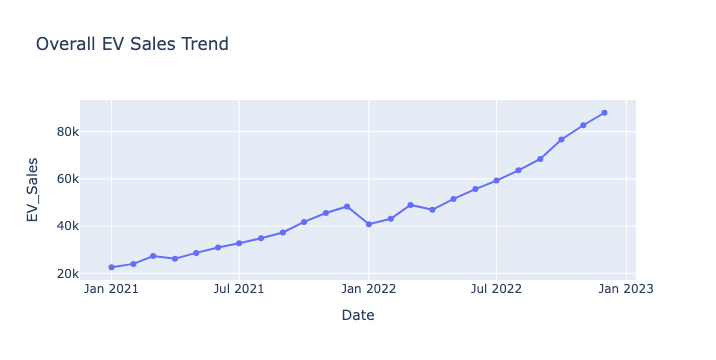

In [9]:
fig = px.line(
    sales_trend,
    x="Date",
    y="EV_Sales",
    markers=True,
    title="Overall EV Sales Trend"
)

fig.show()

**Section 5: Year-wise Sales**

In [10]:
yearly = (
    df.groupby("Year")["EV_Sales"]
      .sum()
      .reset_index()
)

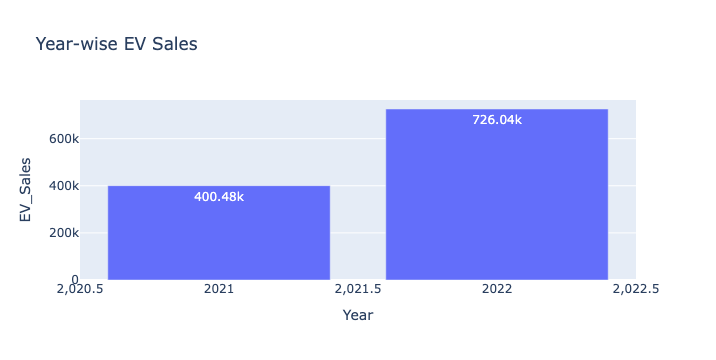

In [11]:
fig = px.bar(
    yearly,
    x="Year",
    y="EV_Sales",
    text_auto=True,
    title="Year-wise EV Sales"
)

fig.show()

**Section 6: Month-wise Sales**

In [12]:
monthly = (
    df.groupby("Month")["EV_Sales"]
      .sum()
      .reset_index()
)

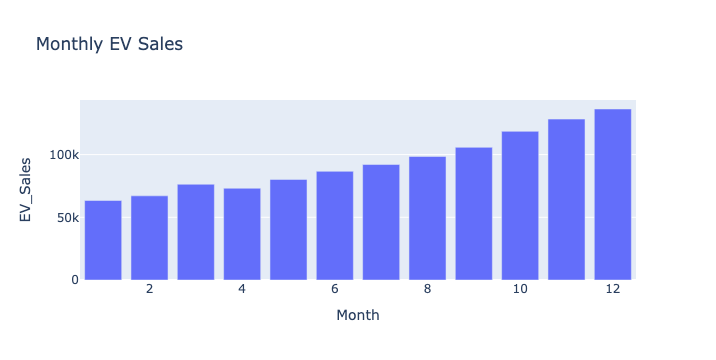

In [13]:
fig = px.bar(
    monthly,
    x="Month",
    y="EV_Sales",
    title="Monthly EV Sales"
)

fig.show()

**Section 7: State-wise Sales**

In [14]:
state = (
    df.groupby("State")["EV_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

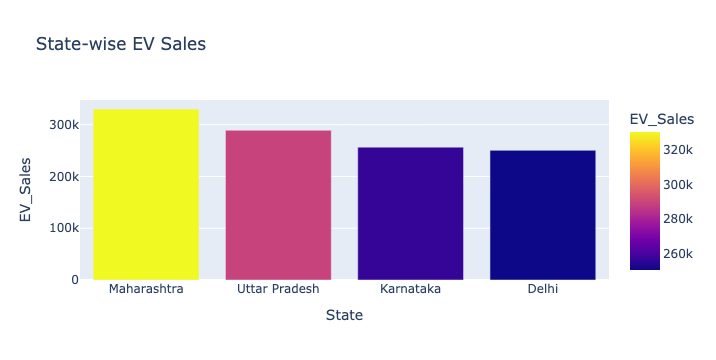

In [15]:
fig = px.bar(
    state,
    x="State",
    y="EV_Sales",
    color="EV_Sales",
    title="State-wise EV Sales"
)

fig.show()

**Section 8: Vehicle Category Analysis**

In [16]:
vehicle = (
    df.groupby("Vehicle_Category")["EV_Sales"]
      .sum()
      .reset_index()
)

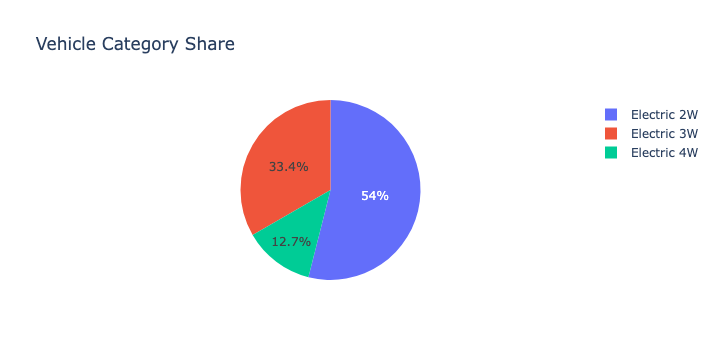

In [17]:
fig = px.pie(
    vehicle,
    names="Vehicle_Category",
    values="EV_Sales",
    title="Vehicle Category Share"
)

fig.show()

**Section 9: Top 10 States**

In [18]:
top10 = (
    df.groupby("State")["EV_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)